# Machine Learning - Classificação 02
- Separação de variáveis
- One Hot Enconding

Algoritimos não lidam bem com texto.. então nesse notebook vamos transformar todas as colunas de texto em 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("marketing_investimento.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


Como separar as features e o target do modelo

In [3]:
X = df.drop('aderencia_investimento', axis= 1)
y = df['aderencia_investimento']
y = (y == "sim").astype(int)

Pré Processamento & One hoting Econding

In [4]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

Se eu tenho 3 categorias, uma dessas colunas será apagada, pois pense:
- Se Solteiro = False
- Se Divorciado = False
Então o único que sobraria seria Casado, mas concorda que Casado == True é igual a os dois seram false?  
```
drop = 'if_binary'
```

In [5]:
colunas = X.columns
colunas

Index(['idade', 'estado_civil', 'escolaridade', 'inadimplencia', 'saldo',
       'fez_emprestimo', 'tempo_ult_contato', 'numero_contatos'],
      dtype='object')

Da pra fazer o one hot via dicionario que é mais python, e da pra fazer com esse código

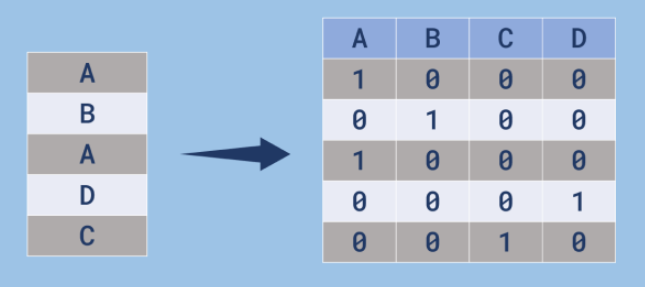

In [6]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), # não converte colunas binarias
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo'] # colunas de objetc
),
    remainder = 'passthrough', # este reminder manter as outras colunas
    sparse_threshold= 0 # faz com que ele mantenha as colunas com os valores originais
    )

In [7]:
X = one_hot.fit_transform(X)

In [8]:
X

array([[ 1.000e+00,  0.000e+00,  0.000e+00, ...,  2.420e+02,  5.870e+02,
         1.000e+00],
       [ 1.000e+00,  0.000e+00,  0.000e+00, ...,  1.289e+03,  2.500e+02,
         4.000e+00],
       [ 0.000e+00,  0.000e+00,  1.000e+00, ...,  3.630e+02,  1.600e+01,
         1.800e+01],
       ...,
       [ 0.000e+00,  0.000e+00,  1.000e+00, ..., -4.770e+02,  1.532e+03,
         2.000e+00],
       [ 1.000e+00,  0.000e+00,  0.000e+00, ...,  2.187e+03,  5.250e+02,
         3.000e+00],
       [ 0.000e+00,  0.000e+00,  1.000e+00, ...,  1.900e+01,  1.100e+02,
         2.000e+00]], shape=(1268, 12))

Salvamos o nome da coluna anteriormente pois o one_hot transforma em um bélissimo Array!

In [9]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [12]:
X = pd.DataFrame(X, columns= one_hot.get_feature_names_out(colunas))
X

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


In [15]:
X.to_csv("marketing_investimento_features.csv", index = True) # vou deixar igual a True por que preciso linkar com o target (y)
y.to_csv("marketing_investimento_target.csv", index = True)